In [14]:
import pandas as pd

acl_df = pd.read_csv("../data/processed/acl_analysis.csv")

analysis_df = acl_df.dropna(
    subset=["score_pct", "tsk_11"]
)

In [15]:
from sklearn.linear_model import LinearRegression

X = analysis_df[["tsk_11"]]
y = analysis_df["score_pct"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.29]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['tsk_11']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,69.41
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [16]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R²:", model.score(X, y))

Intercept: 69.40970978388192
Slope: 0.2942057916977201
R²: 0.036130894370282385


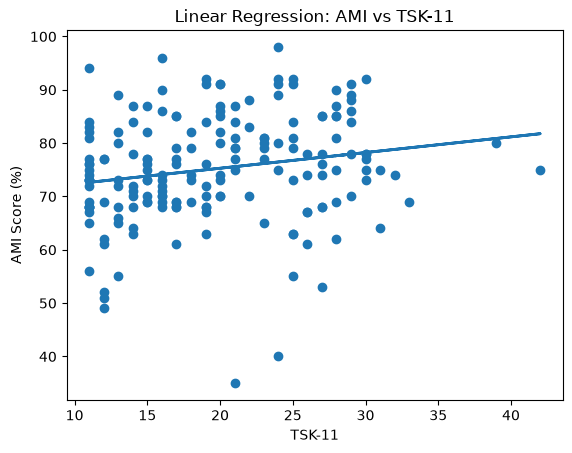

In [17]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
    linewidth=2
)

plt.xlabel("TSK-11")
plt.ylabel("AMI Score (%)")
plt.title("Linear Regression: AMI vs TSK-11")

plt.show()

## Linear Regression Analysis

A simple linear regression model was fit to evaluate the relationship between TSK-11 score and AMI score among ACL patients.

The regression line demonstrates a slight positive slope, indicating that higher TSK-11 scores were associated with marginally higher AMI scores. However, the relationship appears weak, as observations are widely dispersed around the fitted line.

Visual inspection of the plot suggests that TSK-11 is not a strong predictor of AMI score in this dataset. Patients with similar TSK-11 scores often exhibited substantially different AMI scores, resulting in considerable variability around the regression line.

These findings are consistent with the previously observed Pearson correlation coefficient (r ≈ 0.19), which indicated only a weak positive association between the two variables.

Overall, the results suggest that fear of movement, as measured by TSK-11, explains only a small portion of the variation in AMI scores among ACL rehabilitation patients. Additional clinical, psychological, or rehabilitation-related factors likely contribute to differences in AMI performance.

In [18]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R²:", model.score(X, y))

Intercept: 69.40970978388192
Slope: 0.2942057916977201
R²: 0.036130894370282385


## Model Results

- Intercept: 69.4
- Slope: 0.294
- R²: 0.036

The model explained approximately 3.6% of the variability in AMI score.